This notebook tests basic simulation by recapitulating a simulated dataset several times and measuring variance.

Imports

In [1]:
import sys
import os
package_path = os.path.abspath("..")
sys.path.insert(0, package_path)
#The path will be managed by conda or whatever on release, but this is fine for now.
import scMPRAforge as scm
import pandas as pd
import numpy as np

In [1]:
#load the autoreload extension
%load_ext autoreload
#reload code on every execution
#(this may break objects)
#you can remove this & do dev in a notebook, then paste into the module when you are done.
%autoreload 2

In [7]:
#dask imports
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster
import socket

Make the dask cluster & client in accordance with resource avail and model size

In [ ]:
cluster=LocalCluster()
#cluster=SLURMCluster(
#    cores=2,#cores per slurm job
#    memory="16G",#memory per slurm job
#    processes=1,#dask workers per slurm job
#    job_extra_directives=["-p ycga", 
#        f"--job-name=simclust_worker",
#        f"--time=2:00:00",
#        f"--output=slave_%j.out"]
#)
client = Client(cluster,
    timeout=f"{5*60}s",   # Client <-> scheduler timeout 
    heartbeat_interval="20s"  # Worker heartbeat interval
)

2025-06-06 15:45:01,791 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:49845' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'model_to_parameters-d2a94dcb35f0faf815ba65efd4bcc407', 'experiment_model-12c6eb6b4cbd687a2a3136f713fa87b7'} (stimulus_id='handle-worker-cleanup-1749239101.791852')
2025-06-06 15:45:01,793 - distributed.scheduler - WARNING - Removing worker 'tcp://127.0.0.1:49848' caused the cluster to lose already computed task(s), which will be recomputed elsewhere: {'experiment_model-0967fa371a2e7d59010a8aaac4d609b8', 'experiment_model-70ba5087ea16d969b378467c2065197e', 'model_to_parameters-052bddf84ad8778c62a9bd99a5d9e6e0', 'model_to_parameters-74b226678a83ab917a0595d20d8526c4'} (stimulus_id='handle-worker-cleanup-1749239101.793261')
2025-06-06 15:45:01,795 - distributed.scheduler - ERROR - Task process_key-df29197915b34d49776c9e120c4d85de marked as failed because 4 workers died while trying to run it
2025-06-06

In [13]:
#cluster.scale(jobs=5)

In [10]:
dat=scm.load_scMPRA_data("/gpfs/gibbs/pi/reilly/tabula_data/simulated/fake_cres.tsv")

In [17]:
#let's make an ortho object out of the data on disc, we'll call 'primordial'
primordial=scm.ortho()
primordial.criss_cross(client=client,dat=dat)
primordial.extract_params(client)

In [43]:
dat.drop(columns="Unnamed: 0",inplace=True)
dat

,cell_bc,rep_id,cre_id,cell_type,umis_mpra_bc
0,AAAAAAAAAACGAATC,1,nobody,brain,0
1,AAAAAAAAAACGAATG,1,nobody,brain,0
2,AAAAAAAAAACGAATT,1,nobody,brain,0
3,AAAAAAAAAACGACAA,1,nobody,brain,0
4,AAAAAAAAAACGACAC,1,nobody,brain,0
...,...,...,...,...,...
14307,AAAAAAAAAACCTGCT,3,neurogene,blood,7
14308,AAAAAAAAAACCTGGA,3,neurogene,blood,26
14309,AAAAAAAAAACCTGGC,3,neurogene,blood,7
14310,AAAAAAAAAACCTGGG,3,neurogene,blood,15


In [76]:
# break out data-frame descriptions of the by-cre and by-cell-type parameters.
description_primordial_by_cre=scm.describe_parameters(client,parameters=primordial.by_cre_parameters.result(),dat=dat,split="cre_id")
description_primordial_by_cre=scm.auto_partition(description_primordial_by_cre,50)

description_primordial_by_cell_type=scm.describe_parameters(client,parameters=primordial.by_cell_type_parameters.result(),dat=dat,split="cell_type")
description_primordial_by_cell_type=scm.auto_partition(description_primordial_by_cell_type,50)


#scm.flatten_param_representation(client,primordial.by_cell_type_parameters.result(),split="cell_type")


2025-06-06 15:45:01,778 - distributed.protocol.core - CRITICAL - Failed to deserialize
Traceback (most recent call last):
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/protocol/core.py", line 175, in loads
    return msgpack.loads(
  File "msgpack/_unpacker.pyx", line 194, in msgpack._cmsgpack.unpackb
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/protocol/core.py", line 172, in _decode_default
    return pickle.loads(sub_header["pickled-obj"], buffers=sub_frames)
  File "/opt/anaconda3/envs/env_tensorzinb/lib/python3.10/site-packages/distributed/protocol/pickle.py", line 92, in loads
    return pickle.loads(x)
AttributeError: Can't get attribute 'anti_split' on <module 'scMPRAforge.core' from '/Users/mcnoon/tabula-rasa/scMPRAforge/core.py'>
2025-06-06 15:45:01,779 - distributed.protocol.core - CRITICAL - Failed to deserialize
Traceback (most recent call last):
  File "/opt/anaconda3/envs/env_tensorzinb/lib/pyth

FutureCancelledError: process_key-b7501e4f8549c43c61646389bf5693d7 cancelled for reason: already forgotten.

2025-06-06 15:45:03,789 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-06 15:45:03,792 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-06 15:45:03,792 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-06 15:45:03,792 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-06 15:45:03,797 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-06 15:45:03,804 - distributed.nanny - ERROR - Worker process died unexpectedly
2025-06-06 15:45:03,809 - distributed.nanny - ERROR - Worker process died unexpectedly


In [74]:
scm.get_cell_counts(client,dat,split="cell_type")

cells
cre_id[everybody] cre_id[neurogene] cre_id[nobody] cre_id[redgene] cre_id[somebody] C(rep_id)[1] C(rep_id)[2] C(rep_id)[3] cell_type       
0                 0                 0              1               0                0            1            0            brain        465
                  1                 0              0               0                1            0            0            brain        465
1                 0                 0              0               0                0            1            0            brain        465
0                 0                 0              0               1                1            0            0            brain        464
                  1                 0              0               0                0            1            0            brain        460
                  0                 0              0               1                0            0            1            brain        457
1                 0                 0              0               0                0            0            1            brain        455
0                 1                 0              0               0                0            0            1            brain        453
1                 0                 0              0               0                1            0            0            brain        451
0                 0                 0              1               0                0            0            1            brain        445
                                                                                    1            0            0            brain        443
                                    1              0               0                0            1            0            brain        443
                                                                                                 0            1            brain        441
                                                                                    1            0            0            brain        440
                                    0              0               1                0            1            0            brain        434
                                                   1               0                0            0            1            blood        523
                                                   0               1                0            1            0            blood        522
1                 0                 0              0               0                0            0            1            blood        514
0                 0                 0              0               1                1            0            0            blood        504
                                    1              0               0                0            1            0            blood        503
1                 0                 0              0               0                1            0            0            blood        501
0                 0                 1              0               0                0            0            1            blood        500
                                                                                    1            0            0            blood        499
                  1                 0              0               0                1            0            0            blood        499
1                 0                 0              0               0                0            1            0            blood        499
0                 0                 0              0               1                0            0            1            blood        498
                                                   1               0                1            0            0            blood        495
                                                                          

In [73]:
scm.get_cell_counts(client,dat,split="cre_id")

cells
C(rep_id)[1] C(rep_id)[2] C(rep_id)[3] cre_id          
0            1            0            nobody       946
             0            1            nobody       941
1            0            0            nobody       939
                                       somebody     968
0            1            0            somebody     956
             0            1            somebody     955
                                       everybody    969
             1            0            everybody    964
1            0            0            everybody    952
0            0            1            redgene      968
             1            0            redgene      958
1            0            0            redgene      938
                                       neurogene    964
0            1            0            neurogene    951
             0            1            neurogene    943

In [14]:
type(description_primordial_by_cre)

dask.dataframe.dask_expr._collection.DataFrame

In [ ]:
def bust_up(working):
    drop_from_zi=['cre_id','cells','nb','theta','p','r','sigmasquare','cell_type']
    #drop_from_zi=[i for i in drop_from_zi if i!=split]
    zi=working.drop(columns=drop_from_zi)
    zi=zi.drop_duplicates().groupby("rep_id").agg('mean')# zi
    nb=working.drop(columns=['rep_id','cells','zi','theta','r','p']).drop_duplicates()# nb
    #need to add spread!
    return {'zi':zi,'nb':nb}

def round_of_simu(description_primordial,split):
    """
    Given a 
    """
    #s for simulated
    s=scm.simulate_from_description(description_primordial).compute()
    

    s=scm.undo_one_hot_encoding(s)
    s=s.rename({'zinb_sample':'umis_mpra_bc'},axis=1)[['rep_id','cre_id','cell_type','umis_mpra_bc']]

    #recap as in recapitulating the primordial parameters
    recap=scm.ortho()
    recap.criss_cross(client=client,dat=s)
    recap.extract_params(client)

    #munge the df into a convienent format
    working=scm.describe_parameters(client,parameters=recap.by_cre_parameters.result(),dat=s,split=split).reset_index()
    working= scm.undo_one_hot_encoding(working)
    return bust_up(working)

#first is primordial, second is fit
cre_to_cre=[]
cre_to_cell_type=[]

for _ in range(1,5):
    cre_to_cre.append(round_of_simu(description_primordial_by_cre,split="cre_id"))
    #cre_to_cell_type.append(round_of_simu(description_primordial_by_cre,split="cell_type"))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [204]:
zi_p=bust_up(scm.undo_one_hot_encoding(description_primordial_by_cre.compute()))['zi']
zi_p=zi_p.copy()
zi_p=zi_p.rename({'zi':'primordial'},axis=1)
print(zi_p)
#

        primordial
rep_id            
1         0.790788
2         0.497086
3         0.901153


In [ ]:
bust_up(scm.undo_one_hot_encoding(description_primordial_by_cre.compute()))['zi']



nb_slot=bust_up(scm.undo_one_hot_encoding(description_primordial_by_cre.compute()))['nb']

sigma_p=nb_slot[['cre_id','sigmasquare']].rename({"sigmasquare":'primordial'},axis=1)
sigma_p.set_index('cre_id',inplace=True)
#sigma_p

nb_p=nb_slot[['cre_id','nb']].rename({"nb":'primordial'},axis=1)
nb_p.set_index('cre_id',inplace=True)





[        primordial
rep_id            
1         0.790788
2         0.497086
3         0.901153,         simulation_0
rep_id              
1           0.778663
2           0.453744
3           0.901929,         simulation_1
rep_id              
1           0.783317
2           0.514226
3           0.903632,         simulation_2
rep_id              
1           0.803808
2           0.499771
3           0.910169,         simulation_3
rep_id              
1           0.790607
2           0.487370
3           0.898500]


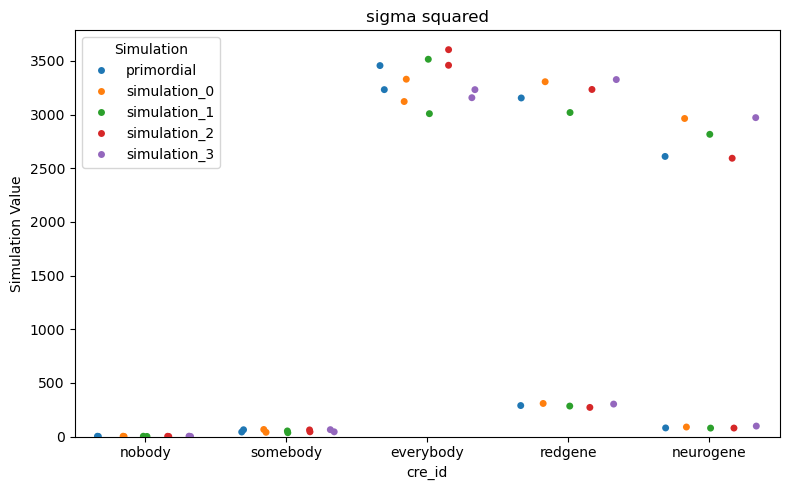

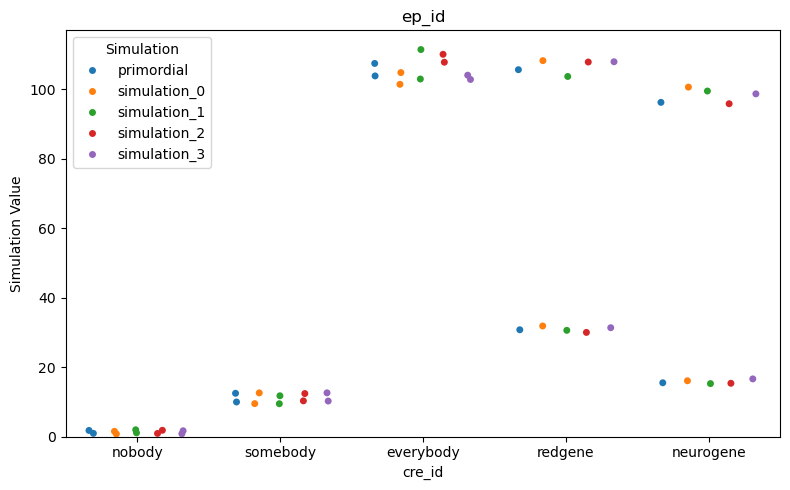

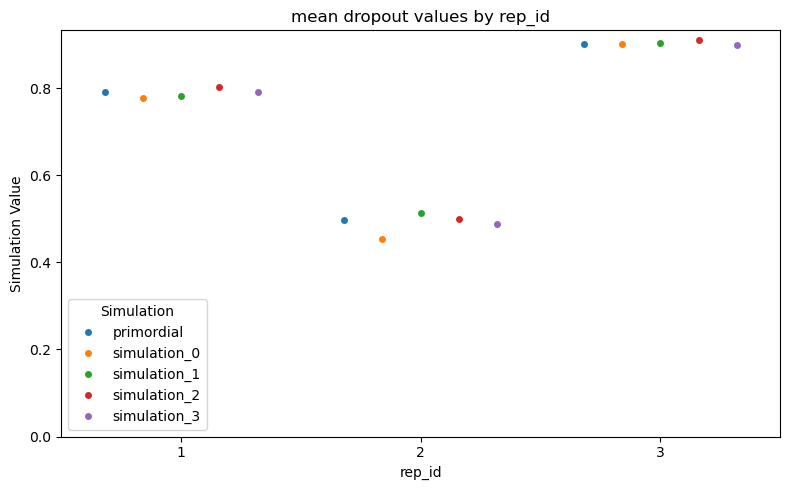

In [205]:
def plot(run):
    zi=[zi_p]
    nb=[nb_p]
    sigma=[sigma_p]
    #zi=[]
    #nb=[]
    #sigma=[]

    for index,dat in enumerate(run):
        df=dat["zi"]
        df=df.rename({"zi":f"simulation_{index}"},axis=1)
        zi.append(df)

        df=dat["nb"][['cre_id','nb']].rename({"nb":f"simulation_{index}"},axis=1)
        df.set_index('cre_id',inplace=True)
        nb.append(df)
        
        df=dat["nb"][['cre_id','sigmasquare']].rename({"sigmasquare":f"simulation_{index}"},axis=1)
        df.set_index('cre_id',inplace=True)
        sigma.append(df)
        #df=df
        
        #sigma.append(df[['cre_id','sigmasquare']])

    print(zi)

    nb_index=nb[0].index
    sigma_index=sigma[0].index

    nb = [df.reset_index(drop=True) for df in nb]
    sigma= [df.reset_index(drop=True) for df in sigma]

    zi=pd.concat(zi,axis=1)
    nb=pd.concat(nb,axis=1)
    sigma=pd.concat(sigma,axis=1)

    sigma.index=sigma_index
    nb.index=nb_index
    
    

    sigma_long= sigma.reset_index().melt(id_vars='cre_id',
                        var_name='simulation', 
                        value_name='value')

    nb_long= nb.reset_index().melt(id_vars='cre_id',var_name="simulation",value_name="value")
    plt.figure(figsize=(8, 5))
    sns.stripplot(data=sigma_long, x='cre_id', y='value', hue='simulation', jitter=True, dodge=True)
    plt.title("sigma squared")
    plt.ylabel("Simulation Value")
    plt.xlabel("cre_id")
    plt.legend(title='Simulation')
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()

    

    nb_long= nb.reset_index().melt(id_vars='cre_id',var_name="simulation",value_name="value")
    plt.figure(figsize=(8, 5))
    sns.stripplot(data=nb_long, x='cre_id', y='value', hue='simulation', jitter=True, dodge=True)
    plt.title("ep_id")
    plt.ylabel("Simulation Value")
    plt.xlabel("cre_id")
    plt.legend(title='Simulation')
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()

    

    zi_long = zi.reset_index().melt(id_vars='rep_id', 
                        var_name='simulation', 
                        value_name='value')
    
    plt.figure(figsize=(8, 5))
    sns.stripplot(data=zi_long, x='rep_id', y='value', hue='simulation', jitter=True, dodge=True)
    plt.title("mean dropout values by rep_id")
    plt.ylabel("Simulation Value")
    plt.xlabel("rep_id")
    plt.legend(title='Simulation')
    plt.tight_layout()
    plt.ylim(bottom=0)
    plt.show()
plot(cre_to_cre)

In [61]:
description_primordial_by_cre

,C(cell_type)[blood],C(cell_type)[brain],C(rep_id)[1],C(rep_id)[2],C(rep_id)[3],cre_id,cells,nb,zi,theta,r,sigmasquare,p
npartitions=2,,,,,,,,,,,,,
0,int64,int64,int64,int64,int64,string,int64,float64,float64,float32,float32,float64,float64
15,...,...,...,...,...,...,...,...,...,...,...,...,...
29,...,...,...,...,...,...,...,...,...,...,...,...,...


In [135]:
cluster.close()